# 00 — Příprava dat
## 4IZ503 Projektový seminář — Ultra Marathon Running
**Dataset:** The Big Dataset of Ultra-Marathon Running (Kaggle) + races_metadata (vlastní Excel)

Tento notebook:
1. Načte hlavní dataset a metadata závodů
2. Provede čištění a validaci dat
3. Odvodí nové sloupce potřebné pro všechny analytické úlohy
4. Exportuje čistý dataset pro další notebooky

> ⚠️ Předpokládaná struktura složek:
> ```
> projekt/
> ├── data/
> │   ├── TWO_CENTURIES_OF_UM_RACES.csv
> │   └── races_metadata_template.xlsx
> ├── notebooks/
> │   └── 00_data_preparation.ipynb  ← tento soubor
> └── data/processed/
>     └── ultra_clean.parquet        ← výstup
> ```


## 1. Import knihoven

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR      = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(exist_ok=True)

print("Knihovny načteny ✓")
print(f"Pandas: {pd.__version__}")
print(f"NumPy:  {np.__version__}")


Knihovny načteny ✓
Pandas: 2.3.3
NumPy:  2.3.5


## 2. Načtení hlavního datasetu

In [2]:
print("Načítám hlavní dataset... (může trvat 30–60 s)")

df = pd.read_csv(DATA_DIR / 'TWO_CENTURIES_OF_UM_RACES.csv', low_memory=False)

print(f"\nNačteno: {len(df):,} řádků, {df.shape[1]} sloupců")
print(f"\nSloupce:")
for col in df.columns:
    print(f"  {col!r:45s} → {df[col].dtype}")


Načítám hlavní dataset... (může trvat 30–60 s)

Načteno: 7,461,195 řádků, 13 sloupců

Sloupce:
  'Year of event'                               → int64
  'Event dates'                                 → object
  'Event name'                                  → object
  'Event distance/length'                       → object
  'Event number of finishers'                   → int64
  'Athlete performance'                         → object
  'Athlete club'                                → object
  'Athlete country'                             → object
  'Athlete year of birth'                       → float64
  'Athlete gender'                              → object
  'Athlete age category'                        → object
  'Athlete average speed'                       → object
  'Athlete ID'                                  → int64


In [3]:
# Ukázka prvních řádků
df.head(3)


,Year of event,Event dates,Event name,Event distance/length,Event number of finishers,Athlete performance,Athlete club,Athlete country,Athlete year of birth,Athlete gender,Athlete age category,Athlete average speed,Athlete ID
0,2018,06.01.2018,Selva Costera (CHI),50km,22,4:51:39 h,Tnfrc,CHI,1978.0,M,M35,10.286,0
1,2018,06.01.2018,Selva Costera (CHI),50km,22,5:15:45 h,Roberto Echeverría,CHI,1981.0,M,M35,9.501,1
2,2018,06.01.2018,Selva Costera (CHI),50km,22,5:16:44 h,Puro Trail Osorno,CHI,1987.0,M,M23,9.472,2


In [4]:
# Přehled chybějících hodnot před čištěním
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}).query('missing_count > 0')


,missing_count,missing_%
Event distance/length,1053,0.01
Athlete performance,2,0.00
Athlete club,2826524,37.88
Athlete country,3,0.00
Athlete year of birth,588161,7.88
Athlete gender,7,0.00
Athlete age category,584938,7.84
Athlete average speed,224,0.00


## 3. Přejmenování sloupců

In [5]:
df = df.rename(columns={
    'Year of event':             'year',
    'Event dates':               'event_dates',
    'Event name':                'event_name',
    'Event distance/length':     'distance_raw',
    'Event number of finishers': 'n_finishers',
    'Athlete performance':       'performance_raw',
    'Athlete club':              'club',
    'Athlete country':           'athlete_country',
    'Athlete year of birth':     'birth_year',
    'Athlete gender':            'gender',
    'Athlete age category':      'age_category_raw',
    'Athlete average speed':     'avg_speed_raw',
    'Athlete ID':                'athlete_id',
})

print("Sloupce přejmenován ✓")
print(df.columns.tolist())


Sloupce přejmenován ✓
['year', 'event_dates', 'event_name', 'distance_raw', 'n_finishers', 'performance_raw', 'club', 'athlete_country', 'birth_year', 'gender', 'age_category_raw', 'avg_speed_raw', 'athlete_id']


## 4. Odvození: věk závodníka

In [6]:
# Věk v době konání závodu (ne aktuální věk)
df['year']       = pd.to_numeric(df['year'],       errors='coerce')
df['birth_year'] = pd.to_numeric(df['birth_year'], errors='coerce')
df['age']        = df['year'] - df['birth_year']

# Filtr realistických věků
n_before = len(df)
df = df[(df['age'] >= 16) & (df['age'] <= 90) | df['age'].isna()]
print(f"Odstraněno nereálných věků: {n_before - len(df):,} řádků")

# Věkové skupiny
bins   = [0, 29, 39, 49, 59, 69, 120]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

print(f"\nRozložení věkových skupin:")
print(df['age_group'].value_counts().sort_index())


Odstraněno nereálných věků: 3,460 řádků

Rozložení věkových skupin:
age_group
18-29     662726
30-39    2085520
40-49    2501992
50-59    1276971
60-69     303676
70+        38689
Name: count, dtype: int64


## 5. Odvození: průměrná rychlost

In [7]:
# avg_speed_raw je string jako "8.234 km/h" nebo "8,234 km/h"
df['avg_speed'] = (
    df['avg_speed_raw']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .str.extract(r'([\d\.]+)')[0]
    .astype(float)
)

# Filtr realistických rychlostí pro ultra (1–25 km/h)
df.loc[(df['avg_speed'] < 1) | (df['avg_speed'] > 25), 'avg_speed'] = np.nan

print("Průměrná rychlost — popis:")
print(df['avg_speed'].describe().round(3))


Průměrná rychlost — popis:
count    6812654.000
mean           7.202
std            2.195
min            1.000
25%            5.642
50%            7.109
75%            8.538
max           25.000
Name: avg_speed, dtype: float64


## 6. Odvození: vzdálenostní kategorie

In [8]:
# Převod distance_raw na číselnou hodnotu v km
def parse_distance(val):
    val = str(val).strip().lower()
    if 'km' in val:
        return pd.to_numeric(val.replace('km', '').strip(), errors='coerce')
    elif 'mi' in val:
        num = pd.to_numeric(val.replace('mi', '').strip(), errors='coerce')
        return num * 1.60934 if pd.notna(num) else np.nan
    return np.nan  # časové závody (24h, 48h, ...)

df['distance_km'] = df['distance_raw'].apply(parse_distance)

# Příznak časového závodu
df['is_timed'] = (
    df['distance_raw'].astype(str).str.contains('h', na=False) &
    ~df['distance_raw'].astype(str).str.contains('km|mi', na=False)
)

# Kategorie vzdálenosti
def dist_cat(row):
    if row['is_timed']:   return 'casovy'
    d = row['distance_km']
    if pd.isna(d):        return np.nan
    elif d < 60:          return 'kratka'    # do 60 km
    elif d < 100:         return 'stredni'   # 60–100 km
    elif d <= 170:        return 'dlouha'    # 100–170 km (cca 100 mil)
    else:                 return 'extremni'  # 170+ km

df['distance_cat'] = df.apply(dist_cat, axis=1)

print("Rozložení vzdálenostních kategorií:")
print(df['distance_cat'].value_counts())
print(f"\nDistanční rozsah (km): {df['distance_km'].min():.1f} – {df['distance_km'].max():.1f}")


Rozložení vzdálenostních kategorií:
distance_cat
kratka      2981274
stredni     2231314
dlouha      1547074
casovy       513100
extremni      78237
Name: count, dtype: int64

Distanční rozsah (km): 24.5 – 5000.0


## 7. Odvození: rychlostní kategorie (relativní)

In [9]:
# Rychlostní kategorie počítáme RELATIVNĚ v rámci stejné distance_cat
# → srovnáváme závodníky se srovnatelnými soupeři, ne napříč vzdálenostmi

def assign_speed_cat(group):
    q33 = group['avg_speed'].quantile(0.33)
    q67 = group['avg_speed'].quantile(0.67)
    conditions = [
        group['avg_speed'] <= q33,
        group['avg_speed'] <= q67,
        group['avg_speed'] >  q67,
    ]
    choices = ['pomalý', 'střední', 'rychlý']
    return pd.Series(np.select(conditions, choices, default=None), index=group.index)

df['speed_cat'] = df.groupby('distance_cat', group_keys=False).apply(assign_speed_cat)

print("Rozložení rychlostních kategorií:")
print(df['speed_cat'].value_counts())


Rozložení rychlostních kategorií:
speed_cat
střední    2281744
pomalý     2215567
rychlý     2214759
Name: count, dtype: int64


## 8. Odvození: zkušenosti závodníka

In [10]:
# Počet startů závodníka PŘED daným závodem (0 = první start)
# Odvozeno kumulativním počítáním závodů per athlete_id seřazených dle roku

print("Počítám zkušenosti závodníků... (může trvat minutu)")

df_sorted = df.sort_values(['athlete_id', 'year'])
df['experience'] = df_sorted.groupby('athlete_id').cumcount()

def exp_cat(n):
    if n == 0:    return 'nováček'   # 1. start
    elif n <= 4:  return 'zkušený'   # 2–5 startů
    else:         return 'veterán'   # 6+ startů

df['experience_cat'] = df['experience'].apply(exp_cat)

print("Rozložení zkušenostních kategorií:")
print(df['experience_cat'].value_counts())


Počítám zkušenosti závodníků... (může trvat minutu)
Rozložení zkušenostních kategorií:
experience_cat
veterán    3337758
zkušený    2480151
nováček    1639826
Name: count, dtype: int64


## 9. Odvození: měsíc a sezóna

In [11]:
# Základní parsování — formát DD.MM.YYYY
df['month'] = pd.to_datetime(df['event_dates'], dayfirst=True, errors='coerce').dt.month

# Fallback — americký formát MM/DD/YYYY
mask_na = df['month'].isna()
df.loc[mask_na, 'month'] = pd.to_datetime(
    df.loc[mask_na, 'event_dates'], dayfirst=False, errors='coerce'
).dt.month

print(f"Po základním parsování — null month: {df['month'].isna().sum():,}")


Po základním parsování — null month: 1,848,018


In [12]:
# Oprava formátu "12.-13.10.2019" (vícedení závody) — vektorizovaně
mask = df['month'].isna()
print(f"Záznamy k opravě: {mask.sum():,}")

fixed_dates = (
    df.loc[mask, 'event_dates']
    .astype(str)
    .str.split('-')
    .str[-1]
    .str.strip()
)

df.loc[mask, 'month'] = pd.to_datetime(
    fixed_dates, dayfirst=True, errors='coerce'
).dt.month

# Výpočet sezóny
season_map = {
    12: 'zima', 1: 'zima',  2: 'zima',
     3: 'jaro', 4: 'jaro',  5: 'jaro',
     6: 'léto', 7: 'léto',  8: 'léto',
     9: 'podzim',10:'podzim',11:'podzim'
}
df['season'] = df['month'].map(season_map)

print(f"Zbývající null month: {df['month'].isna().sum():,} ({df['month'].isna().sum()/len(df)*100:.2f}%)")
print(f"\nRozložení sezón:")
print(df['season'].value_counts())


Záznamy k opravě: 1,848,018
Zbývající null month: 999 (0.01%)

Rozložení sezón:
season
jaro      2576875
léto      2163628
podzim    1939057
zima       777176
Name: count, dtype: int64


## 10. Odvození: dekáda

In [13]:
df['decade'] = (df['year'] // 10 * 10).astype('Int64').astype(str) + 's'
df.loc[df['year'].isna(), 'decade'] = np.nan

print("Rozložení dekád (od 1990):")
print(df[df['year'] >= 1990]['decade'].value_counts().sort_index())


Rozložení dekád (od 1990):
decade
1990s     450283
2000s    1017290
2010s    4526269
2020s    1070948
Name: count, dtype: int64


## 11. JOIN s metadaty závodů

In [14]:
meta = pd.read_excel(DATA_DIR / 'races_metadata_template.xlsx', sheet_name='races_metadata')

print(f"Metadata: {len(meta)} závodů")
print(f"Sloupce:  {meta.columns.tolist()}")
meta.head(3)


Metadata: 99 závodů
Sloupce:  ['event_name', 'runners_count', 'country', 'typical_distance_km', 'elevation_gain_m', 'elevation_loss_m', 'surface', 'source_url', 'notes']


,event_name,runners_count,country,typical_distance_km,elevation_gain_m,elevation_loss_m,surface,source_url,notes
0,Two Oceans Marathon (RSA),263574,ZAF,56.0,700.0,700.0,road,https://www.twooceansmarathon.org.za/ultra-mar...,"56 km ultramarathon, Kapský poloostrov, JAR"
1,Comrades Marathon - Down Run (RSA),224491,ZAF,90.0,1166.0,2200.0,road,https://www.comrades.com/,"Pietermaritzburg → Durban, klesavý směr"
2,Comrades Marathon - Up Run (RSA),221162,ZAF,87.0,1800.0,1160.0,road,https://www.comrades.com/,"Durban → Pietermaritzburg, stoupavý směr"


In [15]:
# Kontrola matchování před JOINem
main_races = set(df['event_name'].unique())
meta_races = set(meta['event_name'].unique())
matched    = main_races & meta_races

print(f"Závodů v hlavním datasetu: {len(main_races):,}")
print(f"Závodů v metadatech:       {len(meta_races)}")
print(f"Matchováno přesně:         {len(matched)}")

unmatched = meta_races - main_races
print(f"\nNenamatchované metadata ({len(unmatched)}):")
for r in sorted(unmatched):
    print(f"  {r!r}")


Závodů v hlavním datasetu: 26,907
Závodů v metadatech:       99
Matchováno přesně:         33

Nenamatchované metadata (66):
  '100 km Lauf Rodenbach (GER)'
  '100 km de Steenvoorde (BEL)'
  'Bigfoot 200 (USA)'
  'Bighorn 100 (USA)'
  'Black Forest Ultra (GER)'
  'Boston Marathon Ultra (USA)'
  'Cape Winelands Ultra (RSA)'
  'Cascade Crest 100 (USA)'
  'Centurion Running (GBR)'
  'Chuckanut 50k (USA)'
  'Comrades Marathon (RSA)'
  'Comrades Marathon - Virtual (RSA)'
  'Diagonale des Fous (REU)'
  'Dolomites Ultra-Trail (ITA)'
  'Ecotrail Paris (FRA)'
  'Eiger Ultra Trail (SUI)'
  'Franken-Ultra (GER)'
  'Glacier 3000 Run (SUI)'
  'Hardrock 100 (USA)'
  'Haria Extreme (ESP)'
  'Highland Fling (GBR)'
  'IAU 100 km World Championship'
  'Javelina Jundred (USA)'
  'Lake Sonoma 50 (USA)'
  'Leadville Trail 100 Run (USA)'
  'MaXi-Race (FRA)'
  'Miwok 100k (USA)'
  'Mogollon Monster 100 (USA)'
  'Mont Blanc Marathon (FRA)'
  'North Face 50 (USA)'
  'Old Dominion 100 (USA)'
  'Orobie Ultra Tra

In [16]:
# Left join — zachováme všechny záznamy z hlavního datasetu
df = df.merge(
    meta[['event_name', 'country', 'typical_distance_km',
          'elevation_gain_m', 'elevation_loss_m', 'surface', 'notes']],
    on='event_name',
    how='left'
)

# Kategorie převýšení
def elev_cat(val):
    if pd.isna(val):   return np.nan
    elif val < 1000:   return 'nízké'
    elif val < 3000:   return 'střední'
    elif val < 6000:   return 'vysoké'
    else:              return 'extrémní'

df['elevation_cat'] = df['elevation_gain_m'].apply(elev_cat)

n_meta = df['surface'].notna().sum()
print(f"Záznamy s metadaty: {n_meta:,} ({n_meta/len(df)*100:.1f}% datasetu)")
print(f"\nRozložení povrchu:")
print(df['surface'].value_counts(dropna=False))


Záznamy s metadaty: 1,446,698 (19.4% datasetu)

Rozložení povrchu:
surface
NaN      6011037
road     1123750
trail     290182
mixed      32766
Name: count, dtype: int64


## 12. Čištění a filtrování

Na základě EDA byly identifikovány následující problémy:

| Problém | Počet záznamů | Řešení |
|---|---|---|
| `athlete_country = 'XXX'` | 1 783 | Odstranit — anonymní závodníci bez identity |
| `year < 1990` | ~380 000 | Odstranit — historická data s vysokým podílem chybějících hodnot |
| `distance_km > 500` | ~600 | Odstranit — víceetapové závody nebo chyby v datech |
| `gender = 'X'` | 46 | Odstranit — zanedbatelný počet, nelze analyticky využít |
| Split závody | 182 901 | Odstranit — duplicitní záznamy hlavních závodů (závodník zaznamenaný na 50km splitu i na plné trati) |


In [17]:
n_before = len(df)

# Filtr základních problémů
df = df[
    (df['athlete_country'] != 'XXX') &
    (df['year'] >= 1990) &
    (df['distance_km'].isna() | (df['distance_km'] <= 500)) &
    (df['gender'].isin(['M', 'F']))
].copy()

print(f"Po základní filtraci: {len(df):,} řádků (odstraněno {n_before - len(df):,})")

# Odstranění Split závodů
n_before_split = len(df)
df = df[~df['event_name'].str.contains('Split|split', na=False)].copy()
print(f"Po odstranění Splitů: {len(df):,} řádků (odstraněno {n_before_split - len(df):,})")
print(f"\nCelkem odstraněno: {n_before - len(df):,} řádků ({(n_before - len(df))/n_before*100:.1f}%)")


Po základní filtraci: 7,060,010 řádků (odstraněno 397,725)
Po odstranění Splitů: 6,877,109 řádků (odstraněno 182,901)

Celkem odstraněno: 580,626 řádků (7.8%)


In [18]:
# Finální přepočet speed_cat na čistém datasetu
df['speed_cat'] = df.groupby('distance_cat', group_keys=False).apply(assign_speed_cat)

print("Finální rozložení speed_cat:")
print(df['speed_cat'].value_counts())


Finální rozložení speed_cat:
speed_cat
střední    2220886
pomalý     2156600
rychlý     2155248
Name: count, dtype: int64


## 13. Finální přehled a vizualizace

In [19]:
print("=" * 55)
print("FINÁLNÍ DATASET — PŘEHLED")
print("=" * 55)
print(f"Řádků:                  {len(df):>10,}")
print(f"Unikátních závodníků:   {df['athlete_id'].nunique():>10,}")
print(f"Unikátních závodů:      {df['event_name'].nunique():>10,}")
print(f"Časové rozmezí:         {int(df['year'].min())} – {int(df['year'].max())}")
print()
print("Pokrytí odvozených sloupců:")
derived = ['age', 'age_group', 'avg_speed', 'speed_cat',
           'distance_km', 'distance_cat', 'experience', 'experience_cat',
           'month', 'season', 'decade', 'surface', 'elevation_cat']
for col in derived:
    n = df[col].notna().sum()
    print(f"  {col:20s} {n:>9,}  ({n/len(df)*100:.1f}%)")


FINÁLNÍ DATASET — PŘEHLED
Řádků:                   6,877,109
Unikátních závodníků:    1,558,306
Unikátních závodů:          23,719
Časové rozmezí:         1990 – 2022

Pokrytí odvozených sloupců:
  age                  6,362,948  (92.5%)
  age_group            6,362,948  (92.5%)
  avg_speed            6,631,522  (96.4%)
  speed_cat            6,532,734  (95.0%)
  distance_km          6,310,395  (91.8%)
  distance_cat         6,774,395  (98.5%)
  experience           6,877,109  (100.0%)
  experience_cat       6,877,109  (100.0%)
  month                6,876,536  (100.0%)
  season               6,876,536  (100.0%)
  decade               6,877,109  (100.0%)
  surface              1,092,215  (15.9%)
  elevation_cat          954,078  (13.9%)


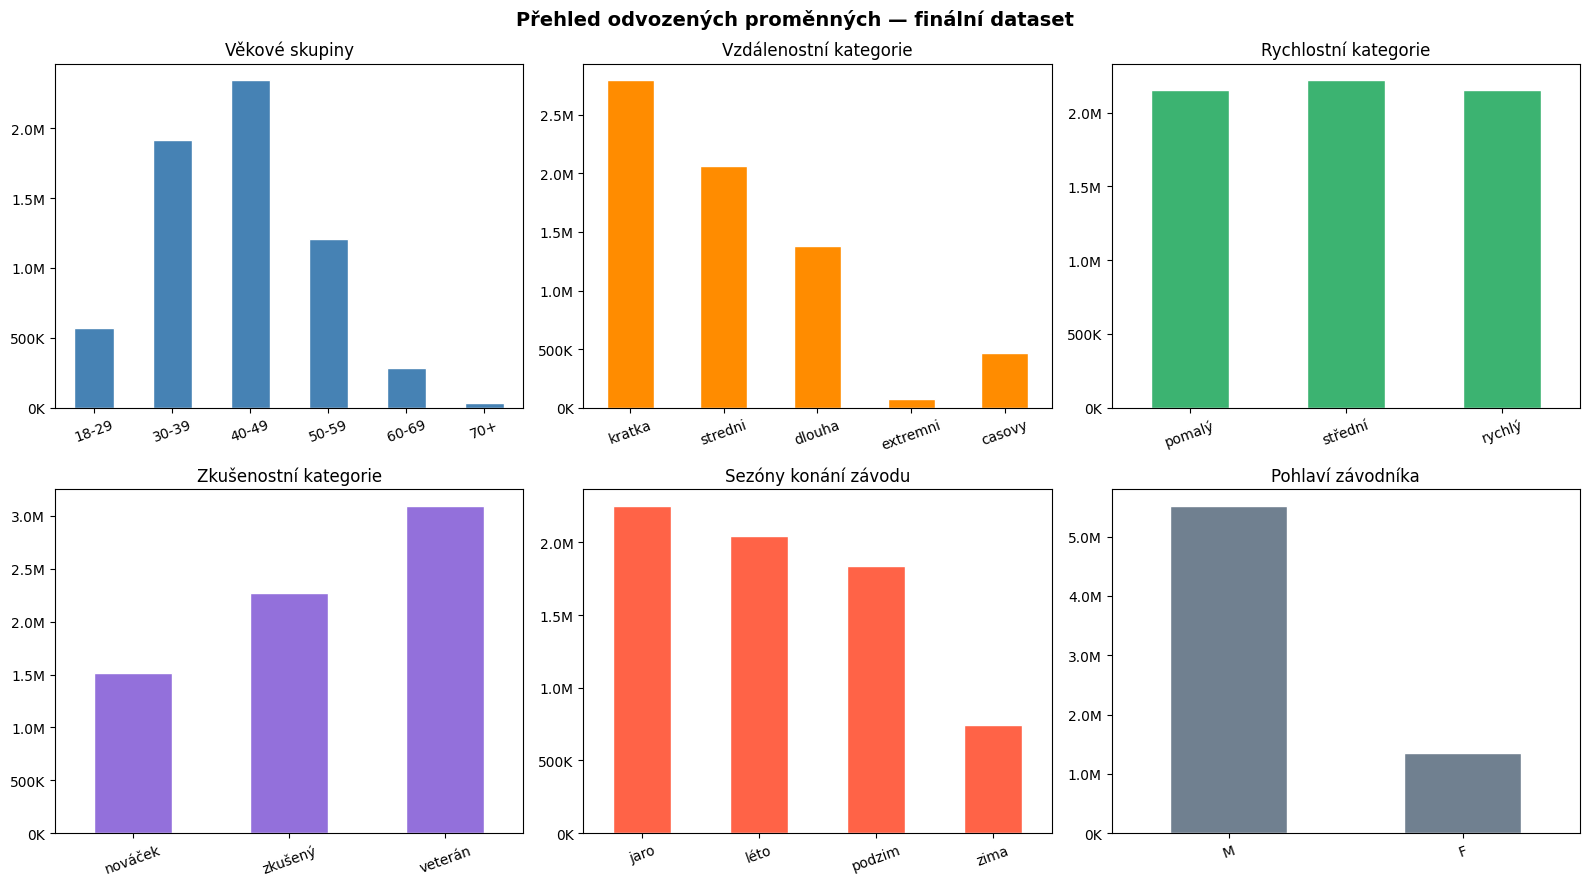

Graf uložen → data/processed/00_overview.png


In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Přehled odvozených proměnných — finální dataset', fontsize=14, fontweight='bold')

plots = [
    ('age_group',      ['18-29','30-39','40-49','50-59','60-69','70+'],  'steelblue',    'Věkové skupiny'),
    ('distance_cat',   ['kratka','stredni','dlouha','extremni','casovy'], 'darkorange',   'Vzdálenostní kategorie'),
    ('speed_cat',      ['pomalý','střední','rychlý'],                     'mediumseagreen','Rychlostní kategorie'),
    ('experience_cat', ['nováček','zkušený','veterán'],                   'mediumpurple',  'Zkušenostní kategorie'),
    ('season',         ['jaro','léto','podzim','zima'],                   'tomato',        'Sezóny konání závodu'),
    ('gender',         ['M','F'],                                         'slategray',     'Pohlaví závodníka'),
]

for ax, (col, order, color, title) in zip(axes.flat, plots):
    vc = df[col].value_counts()
    vc = vc.reindex([o for o in order if o in vc.index])
    vc.plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(PROCESSED_DIR / '00_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graf uložen → data/processed/00_overview.png")


## 14. Export

In [21]:
cols_export = [
    'year', 'event_name', 'distance_raw', 'distance_km', 'distance_cat', 'is_timed',
    'n_finishers', 'athlete_id', 'athlete_country', 'gender', 'birth_year',
    'age', 'age_group', 'avg_speed', 'speed_cat',
    'experience', 'experience_cat', 'month', 'season', 'decade',
    'country', 'typical_distance_km', 'elevation_gain_m', 'elevation_loss_m',
    'surface', 'elevation_cat', 'notes'
]

out_path = PROCESSED_DIR / 'ultra_clean.parquet'
df[cols_export].to_parquet(out_path, index=False, compression='snappy')

size_mb = out_path.stat().st_size / 1024 / 1024
print(f"Uloženo:  {out_path}")
print(f"Velikost: {size_mb:.1f} MB")
print(f"Řádků:    {len(df):,}")
print(f"Sloupců:  {len(cols_export)}")


Uloženo:  ..\data\processed\ultra_clean.parquet
Velikost: 69.6 MB
Řádků:    6,877,109
Sloupců:  27


In [22]:
# Verifikace
df_check = pd.read_parquet(out_path)
assert len(df_check) == len(df), "Počet řádků nesedí!"
print(f"Verifikace OK ✓ — {len(df_check):,} řádků")
print(df_check.dtypes)


Verifikace OK ✓ — 6,877,109 řádků
year                      int64
event_name               object
distance_raw             object
distance_km             float64
distance_cat             object
is_timed                   bool
n_finishers               int64
athlete_id                int64
athlete_country          object
gender                   object
birth_year              float64
age                     float64
age_group              category
avg_speed               float64
speed_cat                object
experience                int64
experience_cat           object
month                   float64
season                   object
decade                   object
country                  object
typical_distance_km     float64
elevation_gain_m        float64
elevation_loss_m        float64
surface                  object
elevation_cat            object
notes                    object
dtype: object


Top 50 závodů bez metadat:
event_name
Penyagolosa Trail MiM-63 (ESP)                      18842
Yatsugatake Nobeyama 100 km (JPN)                   18080
Grand Raid Réunion - La Diagonale des Fous (FRA)    17920
Six Foot Track (AUS)                                17668
Loskop Ultra Marathon 50km (RSA)                    17399
Ultramarathon Okumusashi (JPN)                      17250
Pistoia-Abetone Ultramarathon (ITA)                 17037
Le Grand Raid de la Réunion (FRA)                   16277
La SaintéLyon 72 km (FRA)                           16260
Way Too Cool 50K Endurance Run (USA)                16239
Marathon des Sables (MAR)                           15928
American River 50 Mile Endurance Run (USA)          14988
50 km di Romagna (ITA)                              14586
Tango 100 km Ultramarathon (JPN)                    13890
La SainteLyon 69 km (FRA)                           13507
Trail 56 Golfe du Morbihan (FRA)                    12762
Trail du Petit Ballon (FRA)       

Nalezeno 20639 fuzzy matchů (score >= 80)
                                                                                                                      event_name                                           matched_to  score
18040                                                                                                  Zugspitz-Ultratrail (GER)                            Zugspitz Ultratrail (GER)    100
9419                                                                                                 Dolomites Ultra Trail (ITA)                          Dolomites Ultra-Trail (ITA)    100
2803                                                                                                    Orobie Ultra-Trail (ITA)                             Orobie Ultra Trail (ITA)    100
109                                                                                                          Chuckanut 50K (USA)                                  Chuckanut 50k (USA)    100
20571        

## Shrnutí

### Výsledný dataset
| Metrika | Hodnota |
|---|---|
| Řádků | 6 877 109 |
| Unikátních závodníků | ~1,56M |
| Unikátních závodů | 23 719 |
| Období | 1990–2022 |

### Odvozené sloupce
| Sloupec | Popis | Pokrytí |
|---|---|---|
| `age` / `age_group` | Věk v době závodu, věková skupina | 92,5% |
| `avg_speed` | Průměrná rychlost v km/h | 96,4% |
| `speed_cat` | Relativní rychlostní kategorie (per distance_cat) | 95,0% |
| `distance_km` / `distance_cat` | Vzdálenost a kategorie | 91,8% |
| `experience` / `experience_cat` | Počet předchozích startů | 100% |
| `month` / `season` / `decade` | Časové atributy | 99,9% |
| `surface` / `elevation_cat` | Z metadat závodů (JOIN) | 15,9% |

### Limitace datasetu
- `surface` a `elevation` dostupné jen pro top ~100 závodů (15,9% záznamů)
- `athlete_id` je lokální index v rámci závodu — `experience` je aproximace
- Dataset dominován USA, FRA, RSA, JPN — závěry nemusí platit globálně
- Ženy tvoří 19,8% datasetu — nižší statistická síla pro gender analýzy

**Další notebook:** `01_4ft_uloha1.ipynb` — Horská zkušenost u starších závodníků
